## Data

### Real Data

In [1]:
from simulator_simple import simulate, SpectrumSimple
import torch

parameters_range={"x0": [450, 500],"x1": [0, 1.5], "x2": [450, 500], "x3": [0, 1.5]}
output_names = ["desorption"]

n_weights = 10
exp_times = torch.linspace(450, 500, n_weights)

simulator = SpectrumSimple(parameters_range, output_names, times=exp_times)


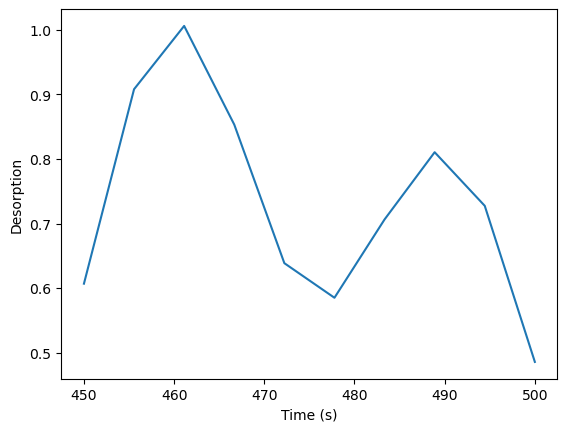

In [2]:
import matplotlib.pyplot as plt


true_parameters = torch.Tensor([[460, 1, 490, 0.8]])

desorption = simulator.forward(true_parameters, allow_failures=False)
plt.plot(simulator.times, desorption.T)
plt.xlabel("Time (s)")
plt.ylabel("Desorption")
plt.show()

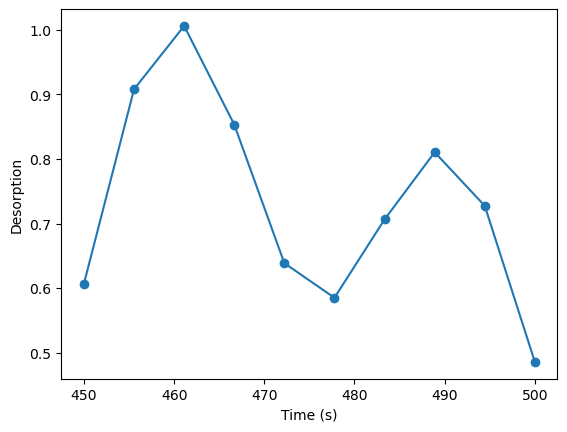

In [3]:
import numpy as np

exp_observation = np.interp(exp_times, simulator.times.numpy(), desorption[0].numpy())
plt.plot(exp_times, exp_observation, marker='o')
plt.xlabel("Time (s)")
plt.ylabel("Desorption")
plt.show()

### Training data

In [4]:
n_samples = 100

input_samples = simulator.sample_inputs(n_samples)

input_samples.shape

torch.Size([100, 4])

In [5]:
y, _ = simulator.forward_batch(input_samples)
y.shape

torch.Size([100, 10])

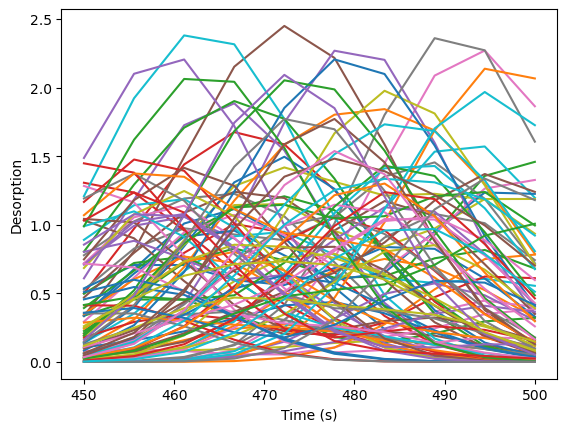

In [6]:
plt.plot(simulator.times, y.T)
plt.xlabel("Time (s)")
plt.ylabel("Desorption")
plt.show()

## Build emulator

In [7]:
from autoemulate import AutoEmulate

AutoEmulate.list_emulators()

,Emulator,PyTorch,Multioutput,Uncertainty_Quantification,Automatic_Differentiation
0,GaussianProcessMatern32,True,True,True,True
1,GaussianProcessRBF,True,True,True,True
2,RadialBasisFunctions,True,True,False,True
3,PolynomialRegression,True,True,False,True
4,MLP,True,True,False,True
5,EnsembleMLP,True,True,True,True


In [8]:
# Run AutoEmulate with default settings
ae = AutoEmulate(input_samples, y, log_level="info", models=["GaussianProcessRBF"])

INFO    2026-01-16 14:12:45,730 - autoemulate - Comparing ['GaussianProcessRBF']
INFO    2026-01-16 14:12:45,731 - autoemulate - Running Model: GaussianProcessRBF: 1/1 (attempt 1/3)
INFO    2026-01-16 14:13:37,725 - autoemulate - Finished running Model: GaussianProcessRBF

INFO    2026-01-16 14:13:37,726 - autoemulate - Using metric 'r2' to determine best result.


In [9]:
ae.summarise()

,model_name,x_transforms,y_transforms,params,r2_test,r2_test_std,rmse_test,rmse_test_std,r2_train,r2_train_std,rmse_train,rmse_train_std
0,GaussianProcessRBF,[StandardizeTransform()],[StandardizeTransform()],"{'epochs': 200, 'lr': 0.1, 'likelihood_cls': <...",0.986406,0.005115,0.045607,0.008007,0.999958,0.000006,0.003285,0.000165


In [10]:
best = ae.best_result()
print("Model with id: ", best.id, " performed best: ", best.model_name)

INFO    2026-01-16 14:13:37,768 - autoemulate - Using metric 'r2' to determine best result.
Model with id:  0  performed best:  GaussianProcessRBF


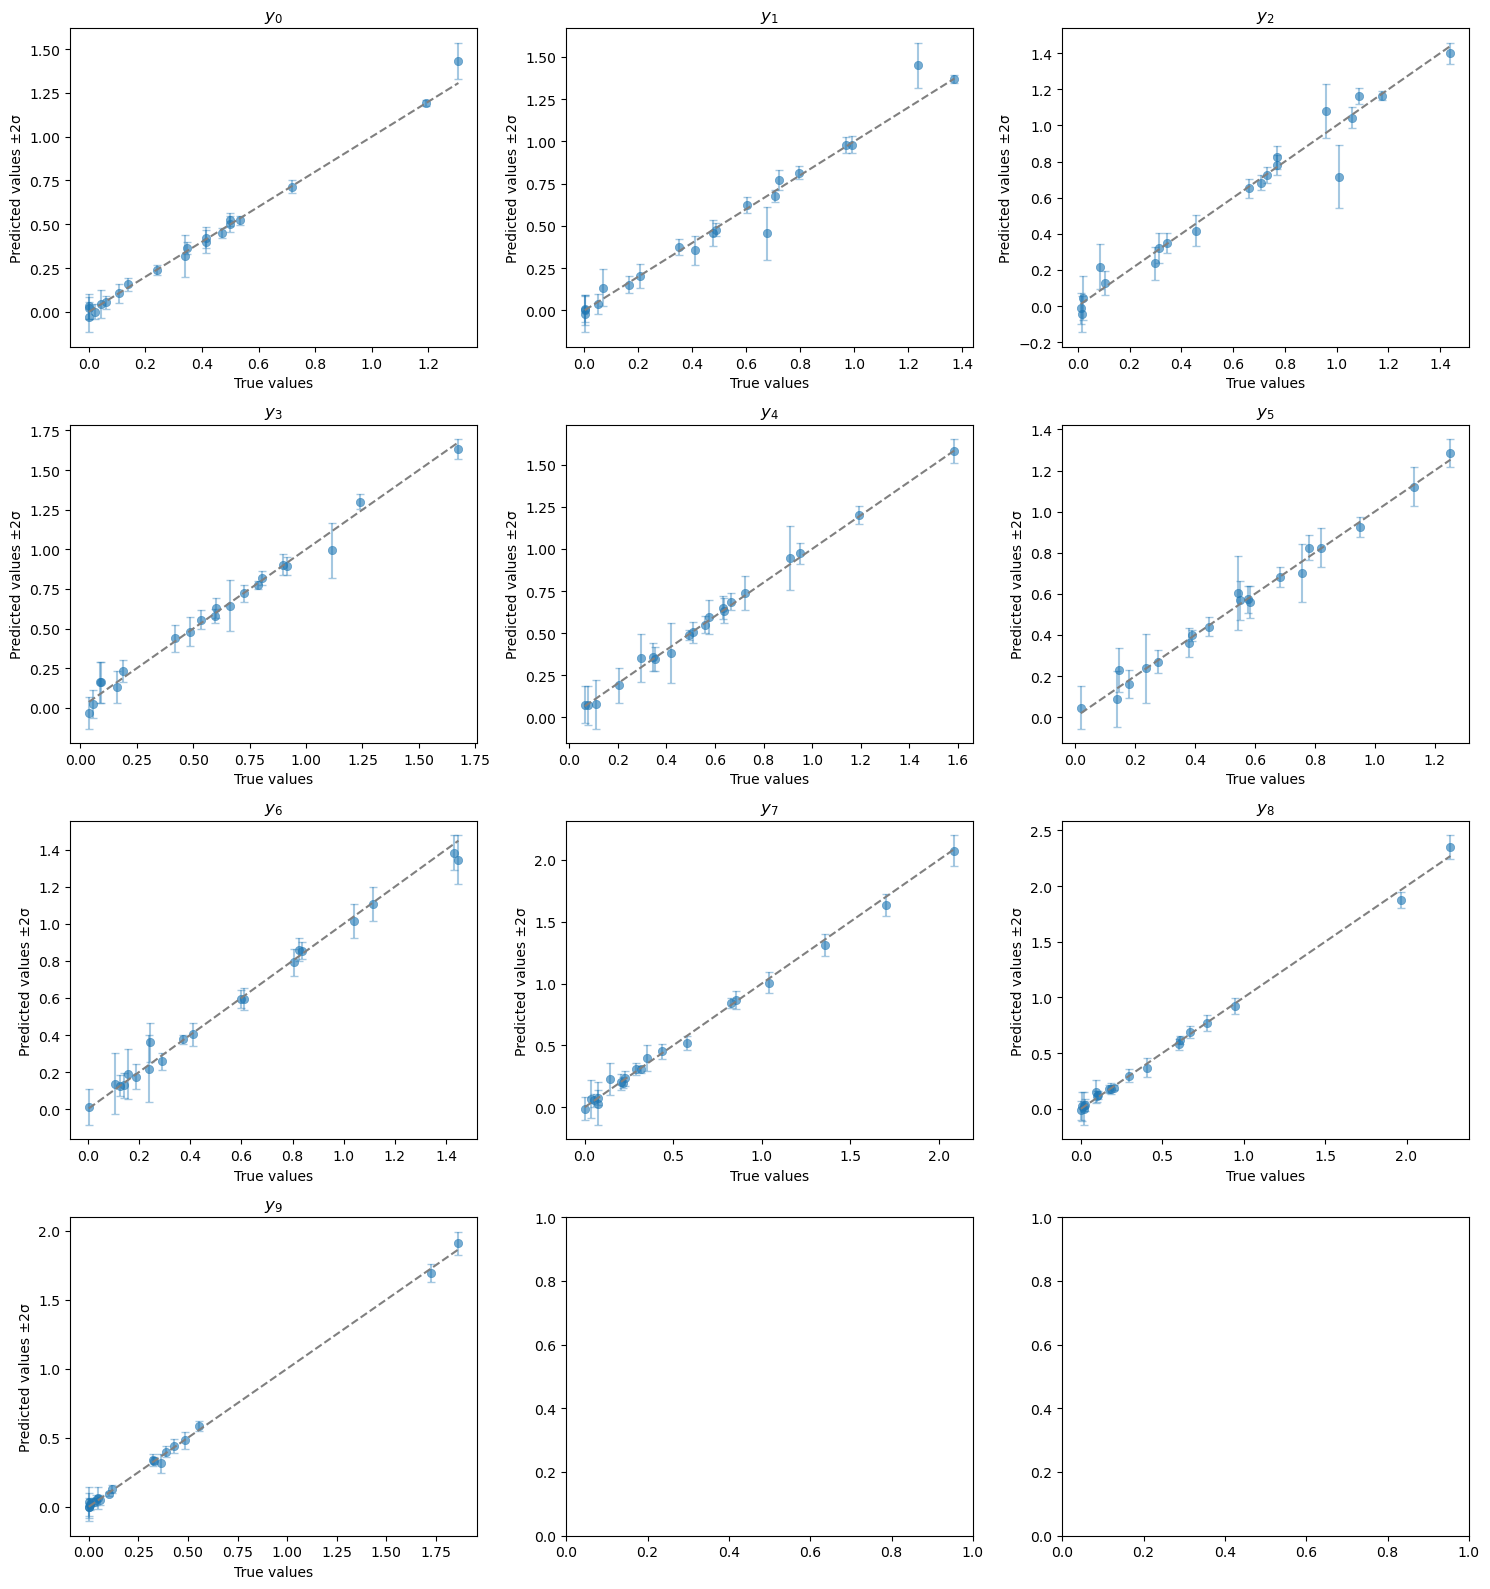

In [11]:
ae.plot_preds(best)

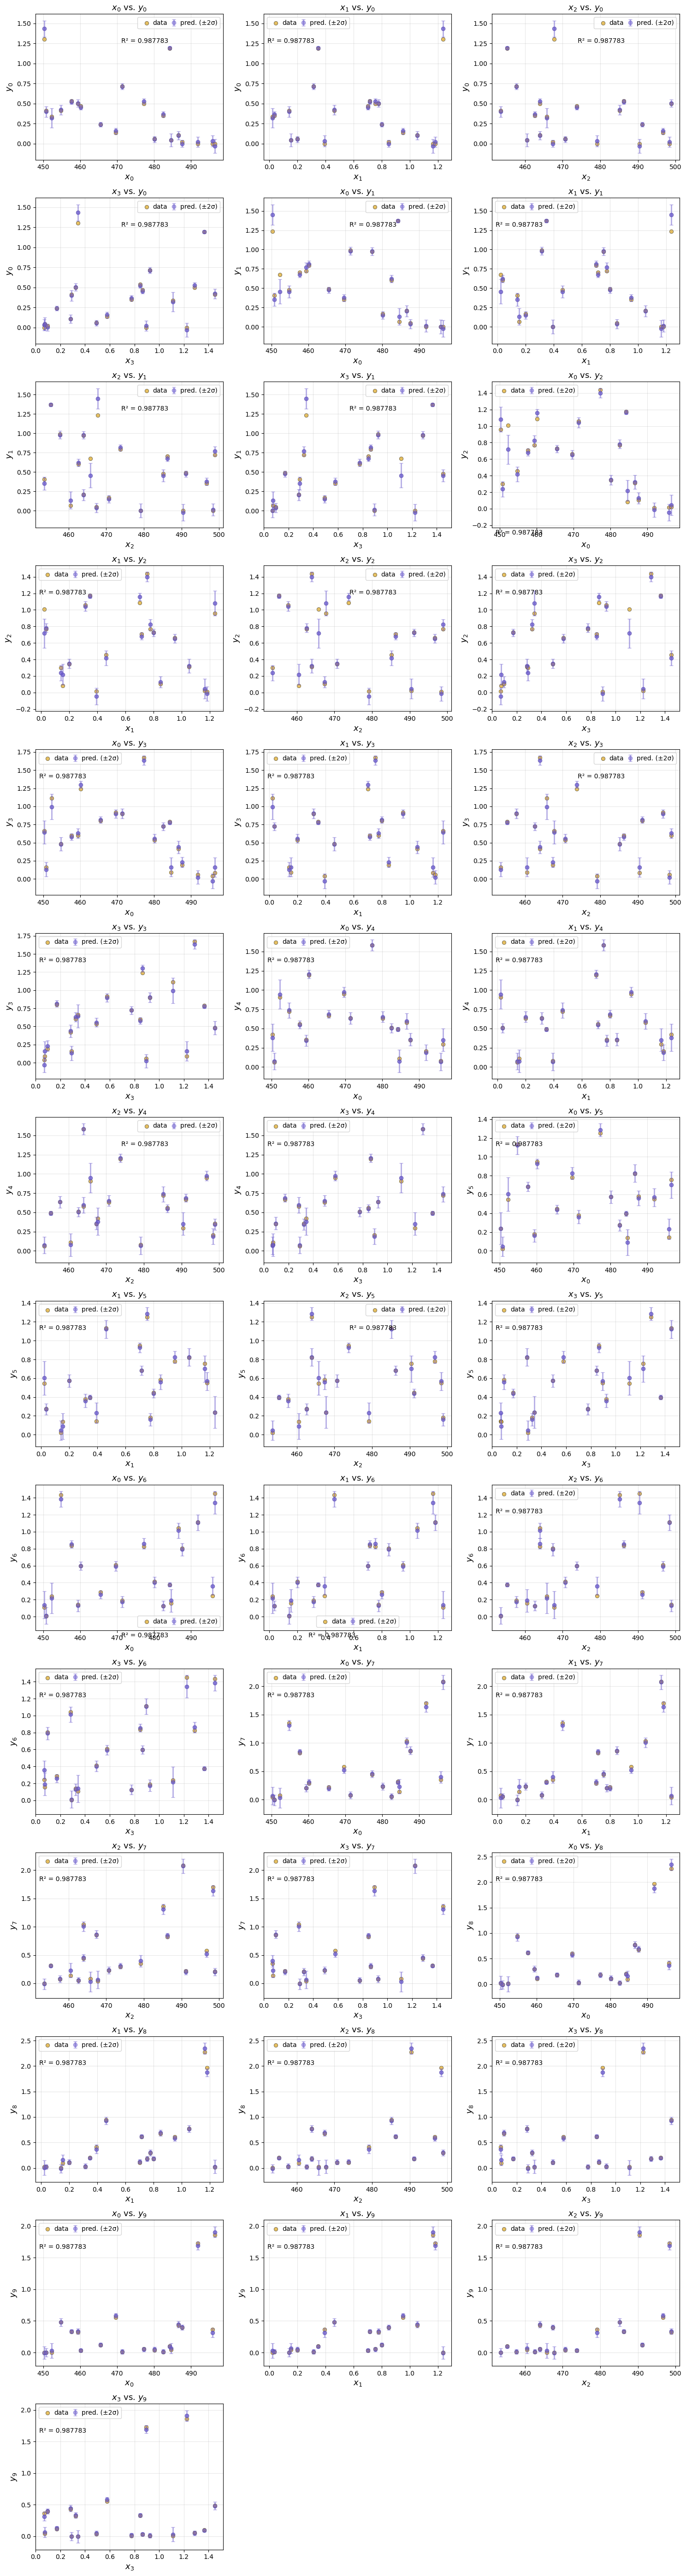

In [12]:
ae.plot(best)

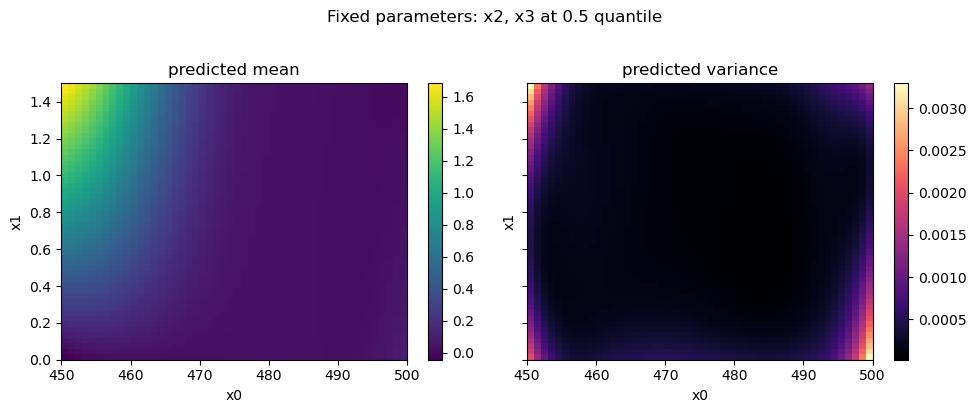

In [13]:
ae.plot_surface(best.model, parameters_range=simulator.parameters_range, quantile=0.5)

INFO    2026-01-16 14:13:42,004 - autoemulate - Using held out test data for calibration plot. To use different data, provide x_test and y_test.


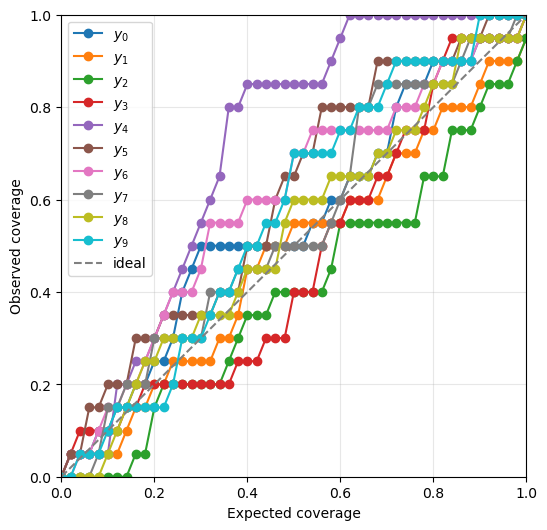

In [14]:
ae.plot_calibration(best.model)

In [28]:
x_test = torch.Tensor([[460, 0.5, 490, 0.5]])

print(best.model.predict(x_test).mean)
print(best.model.predict(x_test).stddev)

tensor([[0.2875, 0.4235, 0.4780, 0.4081, 0.3086, 0.3183, 0.4341, 0.5094, 0.4567,
         0.2968]])
tensor([[0.0149, 0.0201, 0.0229, 0.0252, 0.0285, 0.0271, 0.0255, 0.0242, 0.0202,
         0.0145]])


In [34]:
# y_sim_test = [simulate(xi.numpy().astype(np.float32)) for xi in x_test]
y_sim_test = simulator.forward(x_test)

print("Simulator outputs:", y_sim_test[0])


Simulator outputs: tensor([0.3034, 0.4543, 0.5046, 0.4332, 0.3399, 0.3399, 0.4332, 0.5046, 0.4543,
        0.3034])


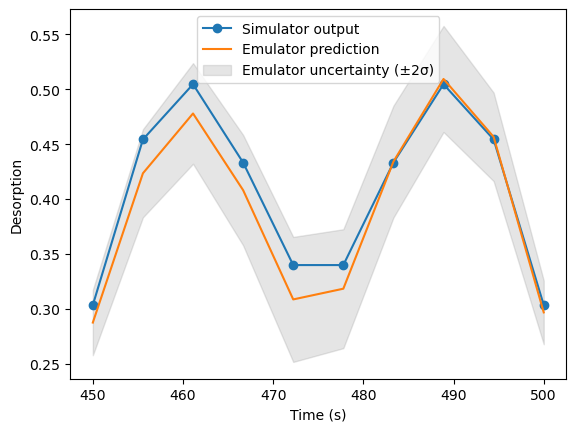

In [37]:
plt.plot(exp_times, y_sim_test.T, label='Simulator output', marker='o')
plt.plot(exp_times, best.model.predict(x_test).mean[0].detach().numpy(), label='Emulator prediction')
plt.fill_between(
    exp_times,
    best.model.predict(x_test).mean[0].detach().numpy() - 2 * best.model.predict(x_test).stddev[0].detach().numpy(),
    best.model.predict(x_test).mean[0].detach().numpy() + 2 * best.model.predict(x_test).stddev[0].detach().numpy(),
    color='gray',
    alpha=0.2,
    label='Emulator uncertainty (±2σ)'
)

plt.xlabel("Time (s)")
plt.ylabel("Desorption")
plt.legend()
plt.show()

## Saving the emulator

In [18]:
# Make a directory to save Emulator models
import os
path = "my_emulators"
if not os.path.exists(path):
    os.makedirs(path)

# The use_timestamp paramater ensures a new result is saved each time the save method is called
best_result_filepath = ae.save(best, path, use_timestamp=True)
print("Model and metadata saved to: ", best_result_filepath)

INFO    2026-01-16 14:13:42,534 - autoemulate - GaussianProcessRBF_0_20260116_141342.joblib saved to my_emulators/GaussianProcessRBF_0_20260116_141342
INFO    2026-01-16 14:13:42,537 - autoemulate - Metadata saved to my_emulators/GaussianProcessRBF_0_20260116_141342_metadata.csv
Model and metadata saved to:  my_emulators/GaussianProcessRBF_0_20260116_141342


## Bayesian calibration

In [39]:
from autoemulate.calibration.bayes import BayesianCalibration

bc = BayesianCalibration(
    best.model, 
    parameter_range=parameters_range, 
    observations={"desorption": torch.Tensor(exp_observation)}, 
    # specify noise as variance
    observation_noise=0.1**2
)

In [ ]:
mcmc_emu = bc.run_mcmc(
    warmup_steps=10, 
    num_samples=50,
    num_chains=2
)

Warmup [1]:   0%|          | 0/60 [00:00, ?it/s]

Warmup [2]:   0%|          | 0/60 [00:00, ?it/s]

/home/remidm/miniconda3/envs/festim-emulate/lib/python3.12/site-packages/torch/utils/_device.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)
/home/remidm/miniconda3/envs/festim-emulate/lib/python3.12/site-packages/torch/utils/_device.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


In [ ]:
mcmc_emu.summary()

print(true_parameters)


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        x0    459.15     12.97    452.41    452.25    491.31      4.10      1.60
        x1      0.60      0.25      0.50      0.41      1.23      6.02      1.15
        x2    470.51     11.35    472.76    451.38    488.90      8.55      2.22
        x3      0.51      0.33      0.38      0.09      1.02      6.59      1.04

Number of divergences: 10
[460, 1, 490, 0.8]


tensor([[0.2875, 0.4235, 0.4780, 0.4081, 0.3086, 0.3183, 0.4341, 0.5094, 0.4567,
         0.2968]])
tensor([[0.0149, 0.0201, 0.0229, 0.0252, 0.0285, 0.0271, 0.0255, 0.0242, 0.0202,
         0.0145]])


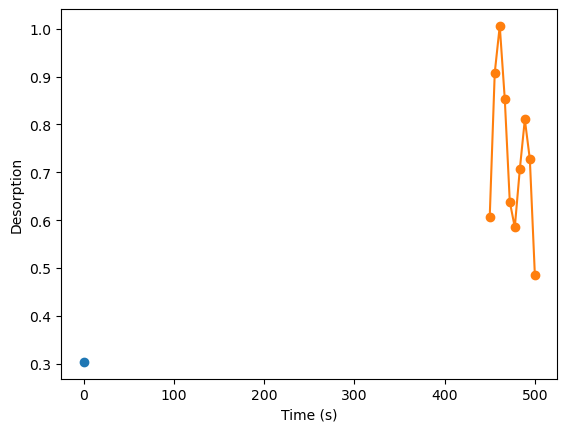

In [38]:
x_found = torch.tensor([[459.15, 0.60, 470.51, 0.51]], dtype=torch.float32)

print(best.model.predict(x_test).mean)
print(best.model.predict(x_test).stddev)

plt.plot(y_sim_test[0][1], y_sim_test[0][0], label='Simulator output', marker='o')
plt.plot(exp_times, exp_observation, marker='o')
plt.xlabel("Time (s)")
plt.ylabel("Desorption")
plt.show()